#Predicting In-Hospital Mortality in Sepsis Patients (MIMIC-IV)


**Goal:** predict in-hospital mortality for adult ICU patients with sepsis, using clinical data from their first 24 hours in the ICU.

**Data:** MIMIC-IV v3.1 (20,963 sepstic ICU patients), extracted with SQL in BigQuery.


##1. Setup

In [132]:
 from google.colab import auth
auth.authenticate_user()

In [133]:
from google.cloud import bigquery

client = bigquery.Client(project="mimic-project-510003")

query = """
SELECT *
FROM `mimic-project-510003.Sepsis_project.cohort_features`
"""

df = client.query(query).to_dataframe()

##2. Exploration

In [186]:
import matplotlib.pyplot as plt

In [134]:
df.shape

(20963, 42)

In [136]:
#overall in-hospital mortality rate (% of patients who died)
df['died_in_hospital'].mean()

np.float64(0.15007393979869293)

In [137]:
#What percentage of patients had lactate measured?
df['has_lactate'].mean()

np.float64(0.728283165577446)

In [138]:
#mortality rate by gender
df.groupby('gender')['died_in_hospital'].mean()

,died_in_hospital
gender,
F,0.162383
M,0.141178


<Axes: ylabel='admission_type'>

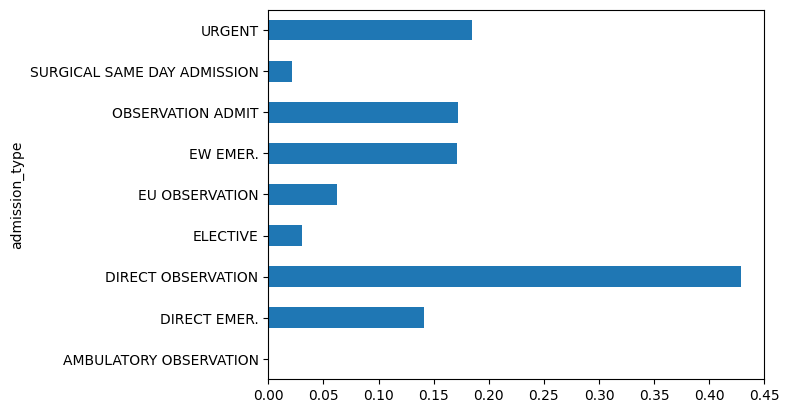

In [139]:
#mortality rate by admission type and plot
df.groupby('admission_type')['died_in_hospital'].mean().plot(kind='barh')

In [140]:
#percentage of missing values per column, most missing first
df.isna().mean().sort_values(ascending=False)

,0
bilirubin_total_max,0.406144
lactate_max,0.271717
temperature_max,0.046367
temperature_min,0.046367
insurance,0.017125
glucose_min,0.004532
glucose_max,0.004532
hemoglobin_min,0.002051
platelets_min,0.001956
wbc_min,0.001908


In [141]:
#compare survivors (0) and death (1): median key features
df.groupby('died_in_hospital')[['bilirubin_total_max', 'sofa_score', 'heart_rate_max', 'wbc_min', 'lactate_max']].median()

,bilirubin_total_max,sofa_score,heart_rate_max,wbc_min,lactate_max
died_in_hospital,,,,,
0,0.8,3.0,102.0,9.6,2.2
1,1.0,4.0,112.0,10.9,3.4


<Axes: title={'center': 'lactate_max'}, xlabel='died_in_hospital'>

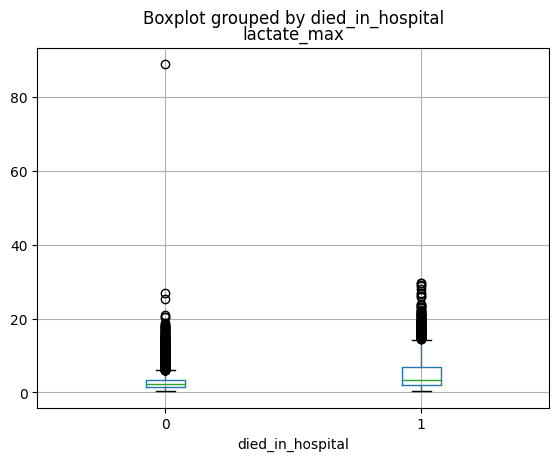

In [142]:
#lactate is clearly higher in death patients even for the typical patient
df.boxplot(column='lactate_max', by='died_in_hospital')

<Axes: title={'center': 'bilirubin_total_max'}, xlabel='died_in_hospital'>

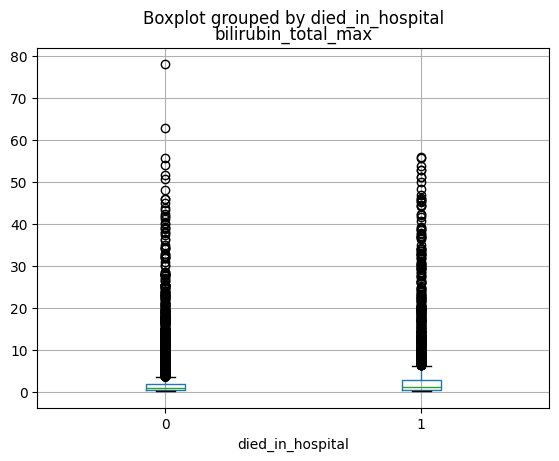

In [143]:
#similar for most patients, the difference comes from a minority with very high values.
df.boxplot(column='bilirubin_total_max', by='died_in_hospital')

In [144]:
df[[ 'temperature_min', 'temperature_max', 'heart_rate_max', 'spo2_min', 'mbp_min']].describe()

,heart_rate_max,spo2_min,mbp_min
count,20962.000000,20956.000000,20962.000000
mean,105.868658,91.225616,56.423481
std,20.881022,7.268276,13.069712
min,38.000000,1.000000,1.000000
25%,91.000000,90.000000,51.000000
50%,103.000000,93.000000,57.000000
75%,118.750000,95.000000,64.000000
max,257.000000,100.000000,115.000000


##3. Cleaning


In [145]:
#temperature is stored as objet not numbers, so its skipped by describe
df[['temperature_min', 'temperature_max', 'heart_rate_max']].dtypes

,0
temperature_min,object
temperature_max,object
heart_rate_max,float64


In [146]:
#convert the temperature from bigQuery's decimal format to numbers
df[['temperature_min', 'temperature_max']] = df[['temperature_min', 'temperature_max']].astype(float)

In [147]:
df[['temperature_min', 'temperature_max']].describe()

,temperature_min,temperature_max
count,19991.000000,19991.000000
mean,36.231386,37.506695
std,0.822044,0.830026
min,15.000000,31.600000
25%,35.940000,37.000000
50%,36.440000,37.330000
75%,36.670000,37.940000
max,39.800000,42.300000


In [148]:
#remove physiologically impossible vital signs (outside plausible range)
df['spo2_min'] = df['spo2_min'].where(df['spo2_min'].between(50, 100))
df['spo2_max'] = df['spo2_max'].where(df['spo2_max'].between(50, 100))
df['temperature_max'] = df['temperature_max'].where(df['temperature_max'].between(25, 45))
df['temperature_min'] = df['temperature_min'].where(df['temperature_min'].between(25, 45))
df['mbp_min'] = df['mbp_min'].where(df['mbp_min'].between(20, 200))
df['mbp_max'] = df['mbp_max'].where(df['mbp_max'].between(20, 200))
df['heart_rate_max'] = df['heart_rate_max'].where(df['heart_rate_max'].between(20, 300))
df['heart_rate_min'] = df['heart_rate_min'].where(df['heart_rate_min'].between(20, 300))

df[['spo2_min', 'spo2_max', 'temperature_min', 'temperature_max', 'mbp_min', 'mbp_max', 'heart_rate_min', 'heart_rate_max']].describe()

,spo2_min,spo2_max,temperature_min,temperature_max,mbp_min,mbp_max,heart_rate_min,heart_rate_max
count,20844.000000,20956.000000,19989.000000,19991.000000,20530.000000,20644.000000,20945.000000,20962.000000
mean,91.541115,99.561176,36.233075,37.506695,57.411739,102.668806,71.745581,105.868658
std,5.776764,1.142915,0.803376,0.830026,11.241980,19.453423,15.401659,20.881022
min,50.000000,66.000000,26.300000,31.600000,20.000000,44.000000,20.000000,38.000000
25%,90.000000,100.000000,35.940000,37.000000,51.000000,89.000000,61.000000,91.000000
50%,93.000000,100.000000,36.440000,37.330000,58.000000,99.000000,70.000000,103.000000
75%,95.000000,100.000000,36.670000,37.940000,64.000000,112.000000,81.000000,118.750000
max,100.000000,100.000000,39.800000,42.300000,115.000000,200.000000,146.000000,257.000000


In [149]:
#check that all values are now within plausible ranges
df[['wbc_min', 'wbc_max', 'hemoglobin_min', 'platelets_min', 'creatinine_max', 'bilirubin_total_max', 'bun_max', 'bicarbonate_min', 'lactate_max']].describe()

,wbc_min,wbc_max,hemoglobin_min,platelets_min,creatinine_max,bilirubin_total_max,bun_max,bicarbonate_min,lactate_max
count,20923.000000,20923.000000,20920.000000,20922.000000,20940.000000,12449.000000,20934.000000,20928.000000,15267.000000
mean,11.033079,15.738906,9.861071,175.530160,1.680086,2.278858,30.906516,21.062901,3.221031
std,8.572068,13.096112,2.127952,102.294873,1.698614,4.852471,24.590312,4.938394,2.899641
min,0.100000,0.100000,1.700000,5.000000,0.100000,0.100000,2.000000,2.000000,0.300000
25%,6.900000,9.900000,8.300000,109.000000,0.800000,0.400000,15.000000,18.000000,1.600000
50%,9.800000,13.900000,9.700000,157.000000,1.100000,0.800000,23.000000,21.000000,2.300000
75%,13.400000,18.800000,11.300000,221.000000,1.800000,1.900000,38.000000,24.000000,3.700000
max,336.700000,471.700000,18.800000,1592.000000,32.300000,78.000000,255.000000,49.000000,89.000000


In [150]:
#remove physiologically impossible lab signs and check now if they are within plausible ranges
df['lactate_max'] = df['lactate_max'].where(df['lactate_max'].between(0, 30))
df['hemoglobin_min'] =  df['hemoglobin_min'].where(df['hemoglobin_min'].between(2, 25))
df[['lactate_max', 'hemoglobin_min']].describe()

,lactate_max,hemoglobin_min
count,15266.000000,20919.000000
mean,3.215412,9.861461
std,2.815389,2.127255
min,0.300000,2.600000
25%,1.600000,8.300000
50%,2.300000,9.700000
75%,3.700000,11.300000
max,29.600000,18.800000


##4. Features and Split

In [151]:
#target in-hospital death (1=died, 0=survived)
y= df['died_in_hospital']
y.mean()

np.float64(0.15007393979869293)

In [152]:
#Features available at hour 24 (ICU length of stay excluded because it is data leakage)
features = [
    'age', 'gender', 'admission_type', 'sofa_score',
    # vital signs
    'heart_rate_min', 'heart_rate_max', 'sbp_min', 'sbp_max',
    'dbp_min', 'dbp_max', 'mbp_min', 'mbp_max',
    'resp_rate_min', 'resp_rate_max', 'temperature_min', 'temperature_max',
    'spo2_min', 'spo2_max', 'glucose_min', 'glucose_max',
    # labs
    'wbc_min', 'wbc_max', 'hemoglobin_min', 'platelets_min',
    'creatinine_max', 'bilirubin_total_max', 'bun_max', 'bicarbonate_min',
    'lactate_max',
    # measured flags
    'has_bilirubin', 'has_lactate'
]

In [153]:
x = df[features]
x.shape

(20963, 31)

In [154]:
from sklearn.model_selection import train_test_split

#split: 80% training, 20% test, stratified so both keep the 15% death rate

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [155]:
x_train.shape
x_test.shape
y_train.mean()
y_test.mean()
print(x_train.shape, x_test.shape)
print(y_train.mean(), y_test.mean())

(16770, 31) (4193, 31)
0.15008944543828265 0.1500119246362986


##5. Preprocessing

In [156]:
#independent copies of the train/test tables
x_train = x_train.copy()
x_test = x_test.copy()

In [157]:
#encode gender as 0/1 (1= female)
x_train['gender'] = (x_train['gender'] == 'F').astype(int)
x_test['gender'] = (x_test['gender'] == 'F').astype(int)
x_train['gender'].mean()

np.float64(0.4182468694096601)

In [158]:
#planned admission flag (elective or same-day surgery)
#based on exploration: 2-3% mortality for planned and 14-18% for unplanned admissions
x_train['planned_admission'] = x_train['admission_type'].isin(['ELECTIVE', 'SURGICAL SAME DAY ADMISSION']).astype(int)
x_train['planned_admission']
x_test['planned_admission'] = x_test['admission_type'].isin(['ELECTIVE', 'SURGICAL SAME DAY ADMISSION']).astype(int)
x_test['planned_admission']

,planned_admission
1693,0
3023,0
3549,0
885,0
18288,0
...,...
2177,0
11051,0
3696,0
15519,0


In [159]:
#drop the original text column (replaced by planned_admission)
x_train = x_train.drop(columns=['admission_type'])
x_test = x_test.drop(columns=['admission_type'])

In [160]:
#medians learned from the training set ony (used to fill both sets to prevent leakage)
train_medians = x_train.median()
train_medians

,0
age,68.0
gender,0.0
sofa_score,3.0
heart_rate_min,70.0
heart_rate_max,103.0
sbp_min,88.0
sbp_max,144.0
dbp_min,44.0
dbp_max,83.0
mbp_min,58.0


In [161]:
#fill missing values with the training medians (both sets prevents leakage)
x_test = x_test.fillna(train_medians)
x_train = x_train.fillna(train_medians)

In [162]:
x_train.isna().sum().sum()
x_test.isna().sum().sum()
# Check: no missing values left in either set
print(x_train.isna().sum().sum(), x_test.isna().sum().sum())

0 0


In [163]:
# Scale features: learned on training (fit_transform), applied to test (transform)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

##6. Model 1: Logistic Regression

In [164]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [165]:
#predicted risk of death for each test patient
test_probs = model.predict_proba(x_test_scaled)[:, 1]

#Auroc:

In [166]:
from sklearn.metrics import roc_auc_score
#AUROC on the test set
roc_auc_score(y_test, test_probs)

np.float64(0.8135144948870439)

In [167]:
#sofa
roc_auc_score(y_test, x_test['sofa_score'])

np.float64(0.6238384106031165)

In [168]:
import pandas as pd

In [169]:
weights = pd.Series(model.coef_[0], index=x_train.columns).sort_values()
weights

,0
planned_admission,-0.569745
wbc_max,-0.315683
spo2_min,-0.194808
temperature_min,-0.186451
sbp_min,-0.180526
creatinine_max,-0.118078
temperature_max,-0.053376
spo2_max,-0.044620
bicarbonate_min,-0.038164
dbp_max,-0.028767


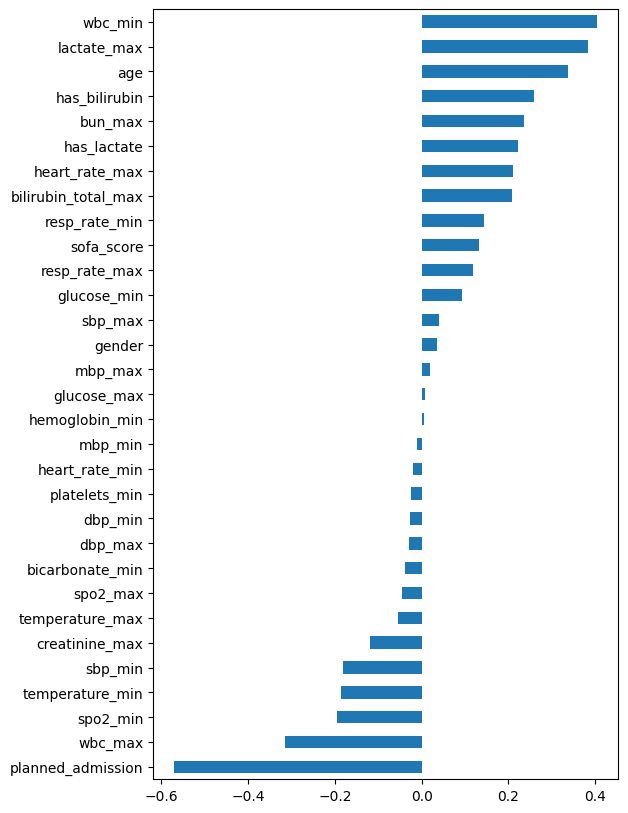

In [170]:
weights.plot(kind='barh', figsize=(6, 10));

##7. XGBoost

In [171]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [172]:
#predicted risks and AUROC on the test.
xgb_probs = xgb.predict_proba(x_test)[:, 1]
roc_auc_score(y_test, xgb_probs)

np.float64(0.8430025390809703)

In [173]:
#overfitting check: training data & test data
roc_auc_score(y_train, xgb.predict_proba(x_train)[:, 1])

np.float64(0.9144813514087506)

##8. Evaluation

In [174]:
#auroc
roc_auc_score(y_test, test_probs)
roc_auc_score(y_test, xgb_probs)
roc_auc_score(y_test, x_test['sofa_score'])

# AUROC on the test set: both models vs the SOFA score alone
print('Logistic regression:', roc_auc_score(y_test, test_probs))
print('XGBoost:', roc_auc_score(y_test, xgb_probs))
print('SOFA alone:', roc_auc_score(y_test, x_test['sofa_score']))

Logistic regression: 0.8135144948870439
XGBoost: 0.8430025390809703
SOFA alone: 0.6238384106031165


In [175]:
from sklearn.metrics import average_precision_score

average_precision_score(y_test, xgb_probs)   # XGBoost
average_precision_score(y_test, test_probs)  # logistic regression

print('Logistic regression:', average_precision_score(y_test, test_probs))
print('XGBoost:', average_precision_score(y_test, xgb_probs))

Logistic regression: 0.4899109758430528
XGBoost: 0.5489320529224982


In [176]:
from sklearn.metrics import precision_score, recall_score

# XGBoost at a 50% cutoff: accurate alarms (precision) but most deaths missed (recall)
flags = xgb_probs > 0.5
print('Patients flagged:', flags.sum(), '| Patients who died:', y_test.sum())
print('Precision:', precision_score(y_test, flags), '| Recall:', recall_score(y_test, flags))

Patients flagged: 250 | Patients who died: 629
Precision: 0.712 | Recall: 0.28298887122416533


In [177]:
#precision and recall at different cutoffs: the trade-off

for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5]:
    flags = xgb_probs > cutoff
    p = precision_score(y_test, flags)
    r = recall_score(y_test, flags)
    print(cutoff, round(p, 2), round(r, 2))

0.1 0.29 0.86
0.2 0.42 0.64
0.3 0.52 0.47
0.4 0.61 0.37
0.5 0.71 0.28


In [178]:
#share of patients flagged at 10% & 20% cutoff (alarm worload)
((xgb_probs) > 0.1).mean()
((xgb_probs) > 0.2).mean()

print((xgb_probs > 0.1).mean(), (xgb_probs > 0.2).mean())

0.444550441211543 0.22847603148103982


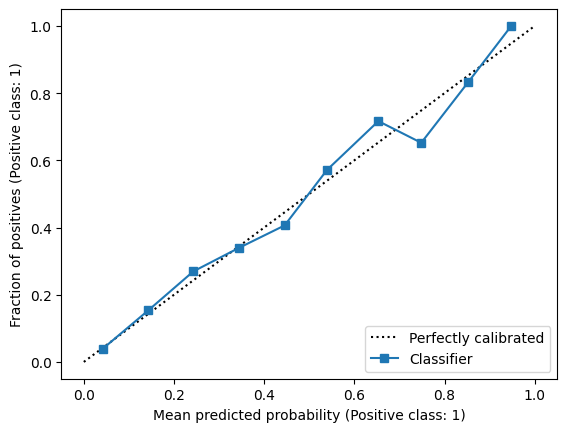

In [188]:
#predicted risks match observed death rates

from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, xgb_probs, n_bins=10)
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show();

##9. Explainability

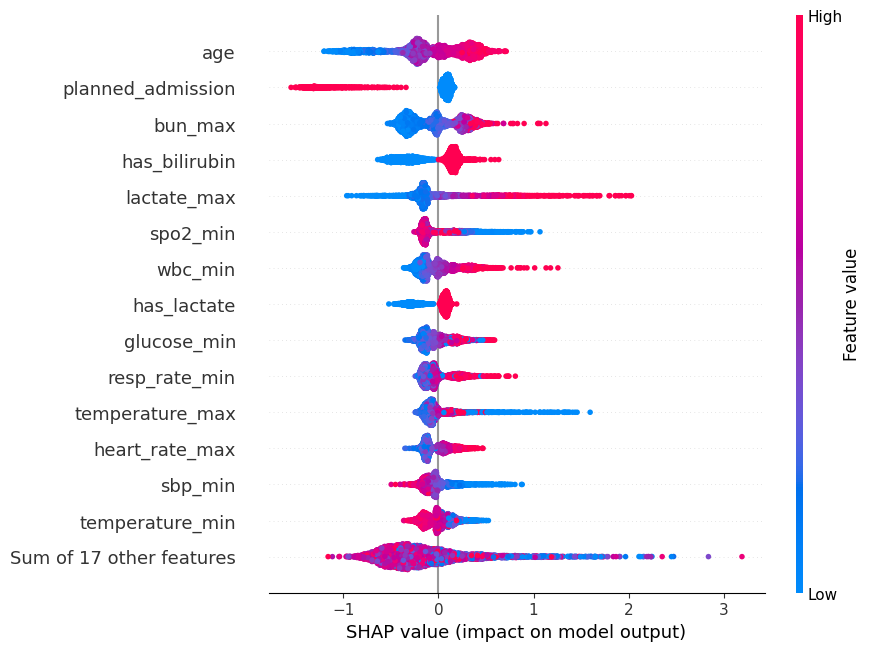

In [187]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(x_test)
# SHAP: which features drive XGBoost's predictions, and in which direction
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

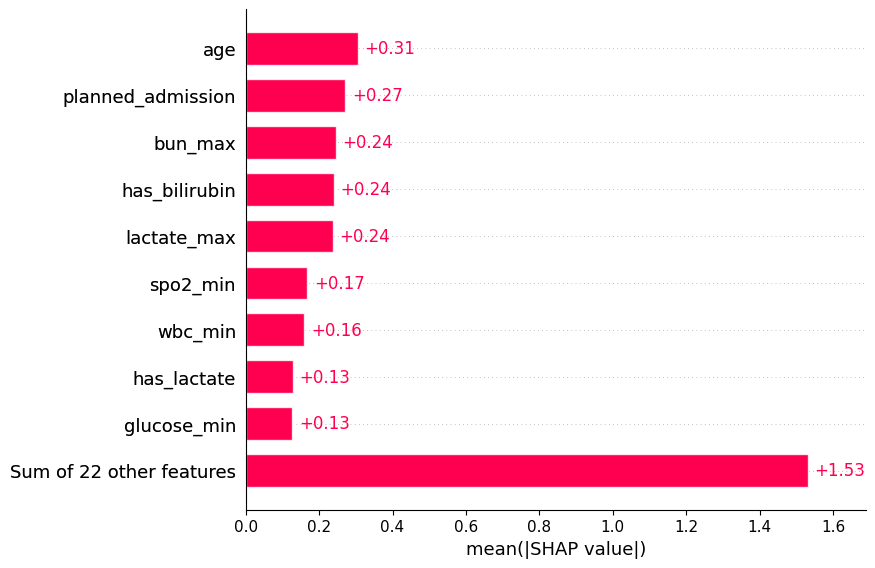

In [181]:
shap.plots.bar(shap_values, max_display=10)

In [182]:
#top 10 features for logistic regression (size of weights), to compare with SHAP

weights = pd.Series(model.coef_[0], index=x_train.columns).abs().sort_values(ascending=False).head(10)
weights

,0
planned_admission,0.569745
wbc_min,0.404237
lactate_max,0.382835
age,0.337007
wbc_max,0.315683
has_bilirubin,0.257870
bun_max,0.236168
has_lactate,0.222299
heart_rate_max,0.209823
bilirubin_total_max,0.208716


In [ ]:
i = xgb_probs.argmax()
xgb_probs[i]
y_test.iloc[i]

In [ ]:
shap.plots.waterfall(shap_values[i])